In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('smartcart_customers.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape

(2240, 22)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handle Missing Values

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [9]:
## Age

df["Age"] = 2026 - df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [10]:
## Customer Joining date

df["Customer_Tenure_Days"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True).max() - pd.to_datetime(df["Dt_Customer"],dayfirst=True) 
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,3,8,10,4,7,0,1,69,663 days
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,6,2,1,1,2,5,0,0,72,113 days
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,42,1,8,2,10,4,0,0,61,312 days
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,5,2,2,0,4,6,0,0,42,139 days
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,15,5,5,3,6,5,0,0,45,161 days


In [11]:
## Spending 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,3,8,10,4,7,0,1,69,663 days,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,1,2,5,0,0,72,113 days,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,1,8,2,10,4,0,0,61,312 days,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,2,2,0,4,6,0,0,42,139 days,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,5,3,6,5,0,0,45,161 days,422


In [12]:
df["Total_Kids"] = df["Kidhome"] + df["Teenhome"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,8,10,4,7,0,1,69,663 days,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,1,2,5,0,0,72,113 days,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,8,2,10,4,0,0,61,312 days,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,2,0,4,6,0,0,42,139 days,53,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,3,6,5,0,0,45,161 days,422,1


In [13]:
df["Education"].value_counts()

# undergraduate, graduate, postgraduate

df["Education"] = df["Education"].replace({"Basic": "Undergraduate", 
                                           "2n Cycle": "Undergraduate", 
                                           "Graduation": "Graduate", 
                                           "Master": "Postgraduate", 
                                           "PhD": "Postgraduate"})
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids
0,5524,1957,Graduate,Single,58138.0,0,0,04-09-2012,58,635,...,8,10,4,7,0,1,69,663 days,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,08-03-2014,38,11,...,1,1,2,5,0,0,72,113 days,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,21-08-2013,26,426,...,8,2,10,4,0,0,61,312 days,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,10-02-2014,26,11,...,2,0,4,6,0,0,42,139 days,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,19-01-2014,94,173,...,5,3,6,5,0,0,45,161 days,422,1


In [14]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
## Marital Status 

df.head()
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [16]:
df["Living_With"] = df["Marital_Status"].replace({"Single": "Alone",
                                                     "Together": "Partner",
                                                     "Married": "Partner",
                                                     "Divorced": "Alone",
                                                     "Widow": "Alone",
                                                     "Alone": "Alone",
                                                     "Absurd": "Alone",
                                                     "YOLO": "Alone"})
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [17]:
## Drop unnecessary columns

df_cleaned = df.drop(columns = ["ID", "Year_Birth", "Dt_Customer", "Marital_Status", "Kidhome", 
                        "Teenhome", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", 
                        "MntSweetProducts", "MntGoldProds"] )


In [18]:
df_cleaned .head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Partner


In [19]:
df_cleaned.shape

(2240, 15)

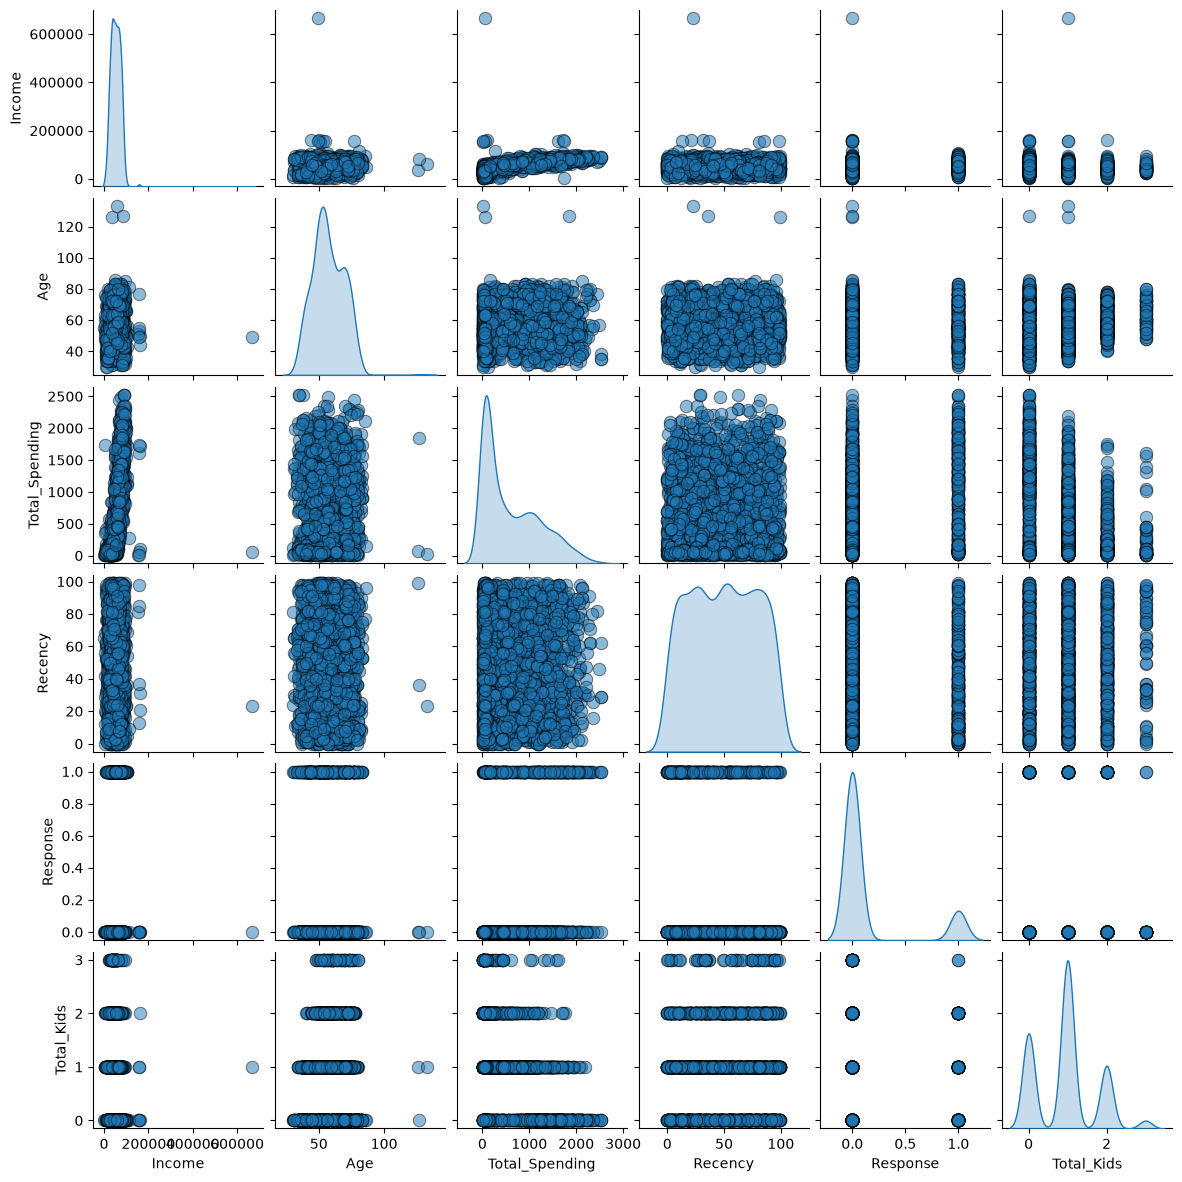

In [20]:
## Looking at outliers: plots can help us

num_cols = ["Income", "Age", "Total_Spending", "Recency","Response", "Total_Kids"]

## Relative plot of some features to see the distribution of the data and outliers

sns.pairplot(df_cleaned[num_cols], diag_kind="kde", plot_kws={"alpha": 0.5, "s": 80, "edgecolor": "k"}, height=2)

In [21]:
## Income > 600,000 will remove and age > 90 
print("data size with outlier", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]

print("data size after removing outlier", len(df_cleaned))

data size with outlier 2240
data size after removing outlier 2236


<Axes: >

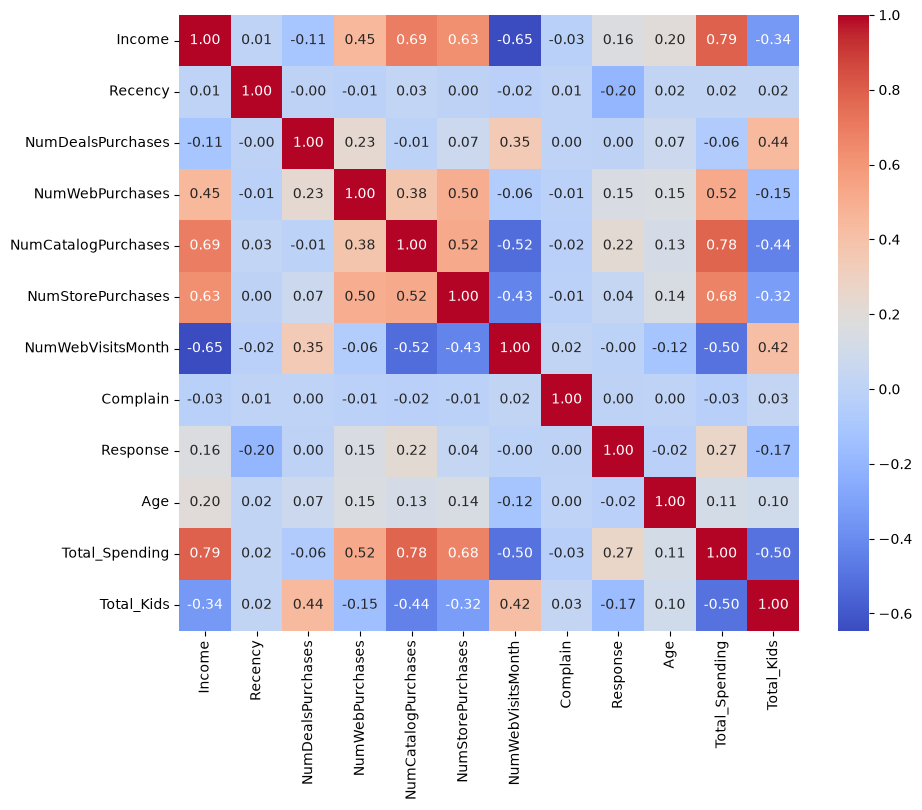

In [22]:
## Correlation matrix to see the correlation between features

plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(numeric_only=True), 
            annot=True, 
            cmap="coolwarm", 
            annot_kws={"size": 10},
            fmt=".2f")

In [23]:
df_cleaned.shape

(2236, 15)

## Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

onehot_encoder = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

encoded_cols = onehot_encoder.fit_transform(df_cleaned[cat_cols])


In [25]:
encoded_cols = pd.DataFrame(encoded_cols.toarray(), columns= onehot_encoder.get_feature_names_out(cat_cols), index = df_cleaned.index)


In [26]:
encoded_cols.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [27]:
encoded_df = pd.concat([df_cleaned.drop(columns=cat_cols), encoded_cols], axis=1)

encoded_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,0.0,1.0


In [28]:
encoded_df["Customer_Tenure_Days"] = encoded_df["Customer_Tenure_Days"].dt.days

encoded_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [29]:
X = encoded_df

## Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
X_scaled.shape

(2236, 18)

## PCA to reduce dimensions

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

In [33]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D PCA Scatter Plot')

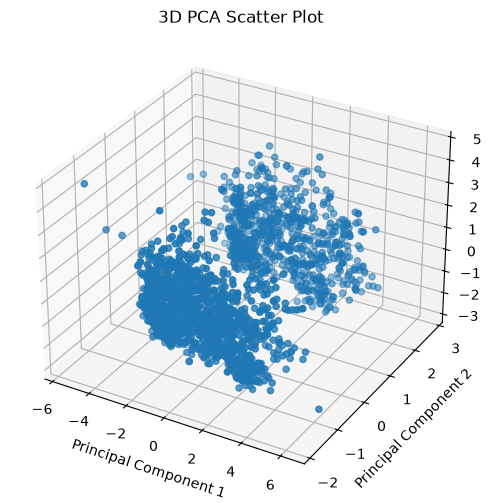

In [34]:
## PLot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Scatter Plot')

## Analyze the K value 
### 1. Elbow method
### 2. Silhouette score

In [35]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    

In [37]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [38]:
print("best K value is: ", optimal_k)

best K value is:  4


Text(0, 0.5, 'WCSS (Within-cluster sum of squares)')

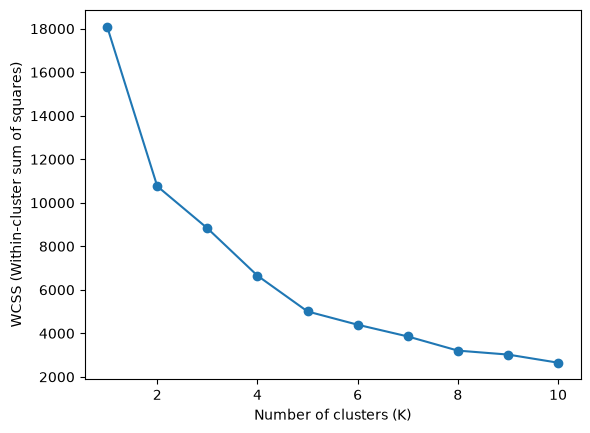

In [39]:
# plot K values

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Within-cluster sum of squares)')

In [40]:
## Silhouette score

from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

Text(0, 0.5, 'Silhouette Score')

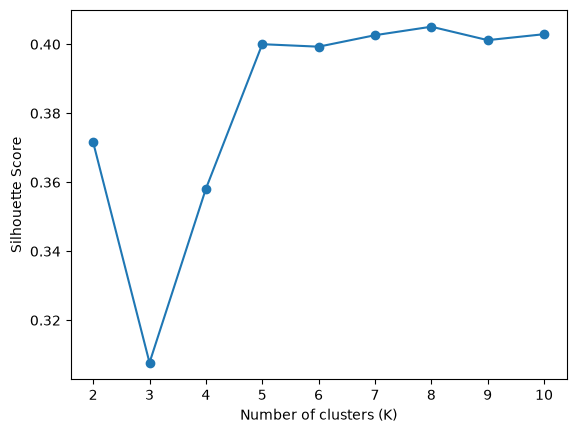

In [41]:
## plot 
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')

Text(0, 0.5, 'Silhouette Score')

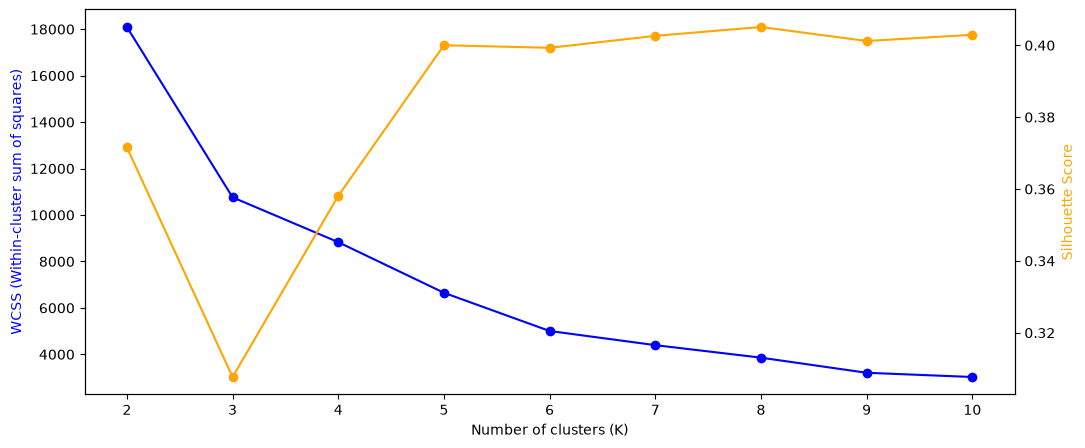

In [42]:
## Combined plot 

k_range = range(2, 11)
fig, ax1 = plt.subplots( figsize=(12, 5))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color = 'blue', label='WCSS')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS (Within-cluster sum of squares)', color='blue')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='o', color = 'orange', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='orange')  


## Apply clustering algorithm

In [43]:
## Kmeans

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
lables_kmeans = kmeans.fit_predict(X_pca)


Text(0.5, 0.92, '3D PCA Scatter Plot with KMeans Clusters')

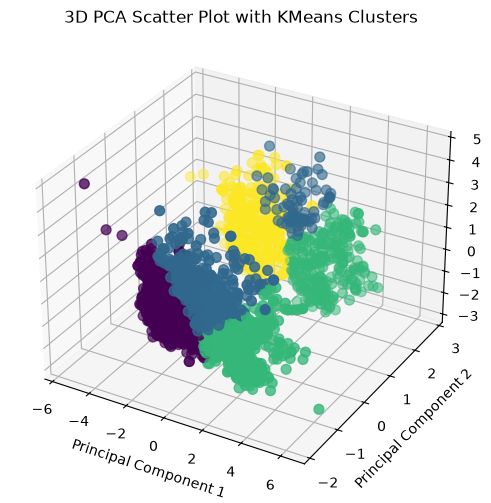

In [44]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=lables_kmeans, cmap='viridis', s=50)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Scatter Plot with KMeans Clusters')

In [45]:
## Aglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_pca)

Text(0.5, 0.92, '3D PCA Scatter Plot with Agglomerative Clusters')

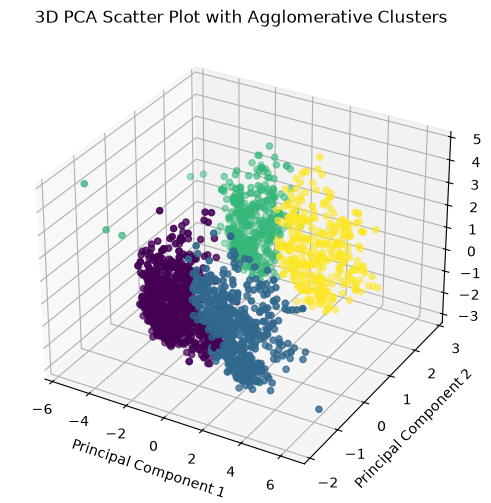

In [46]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agg_labels, cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Scatter Plot with Agglomerative Clusters')

## Profiling/Chacaterisation of the clusters

In [51]:
X["labels"] = agg_labels

In [52]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Kids,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


/tmp/ipykernel_62471/2703940056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X["labels"],  palette=pal)


<Axes: xlabel='labels', ylabel='count'>

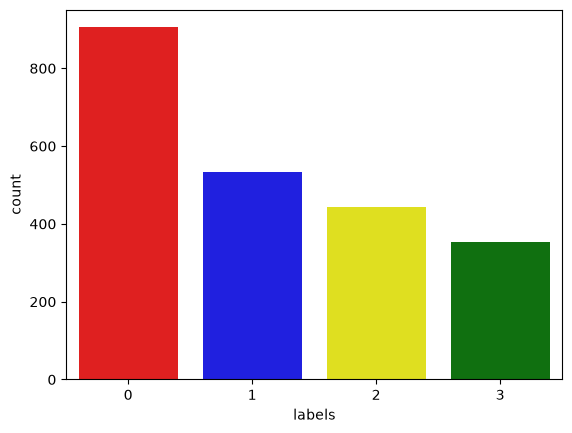

In [53]:
pal = ['red', "blue", "yellow", "green"]

sns.countplot(x=X["labels"],  palette=pal)

<Axes: xlabel='Total_Spending', ylabel='Income'>

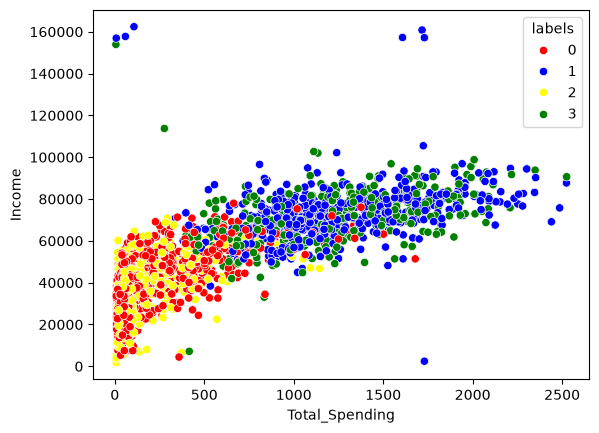

In [54]:
## Income and spending patterns 

sns.scatterplot(x= X["Total_Spending"], y = X["Income"], hue=X["labels"], palette=pal)

In [ ]:
# Lebel 0 : Red >> Low or Moderate Income Range, Low & Moderate Spending Range
# Label 1 : Blue >> High Income Range, High Spending Range
# Label 2 : Yellow >> Spending and Income both are low 
# Lable 3 : Green >> Moderate Income Range, High Spending Range

In [58]:
## Cluster Summary

cluster_summary = X.groupby("labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_Spending  Total_Kids  \
labels           

In [ ]:
# Label 1 and 3 are the most profitable customers for the business, and they have less number of children, slightly higher age
# Label 0 and 2 are price sensitive customers for the business, They have more number of children, slighly lower age
# Label 3 gave best response
# Average response for 1,2 Labels and poor response for 0 
# Label 0 and 1 mostly live with their partner, while Label 2 and 3 mostly live alone.
# Label 0 and 2 have higher website visits
# Label 1 and 3 has lower website visits, but they have higher spending and income
# Label 1 and 3 are purhcasing more from catelog and store. 
# Label 0 and 2 has lower purchases in all categories. 